In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Work/Fraud Detection Data Set 25.02.206.xls')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            499 non-null    int64  
 1   type            499 non-null    object 
 2   amount          499 non-null    float64
 3   nameOrig        499 non-null    object 
 4   oldbalanceOrg   499 non-null    float64
 5   newbalanceOrig  499 non-null    float64
 6   nameDest        499 non-null    object 
 7   oldbalanceDest  499 non-null    float64
 8   newbalanceDest  499 non-null    float64
 9   isFraud         499 non-null    int64  
 10  isFlaggedFraud  499 non-null    int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 43.0+ KB


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,499.0,4.990000e+02,4.990000e+02,4.990000e+02,4.990000e+02,4.990000e+02,499.000000,499.0
mean,1.0,1.436363e+05,1.042359e+06,1.073432e+06,6.042126e+05,1.244463e+06,0.008016,0.0
std,0.0,2.922379e+05,2.228056e+06,2.279903e+06,1.732090e+06,3.656649e+06,0.089262,0.0
min,1.0,8.730000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.0,4.823120e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,1.0,3.232524e+04,1.155839e+04,2.958910e+03,7.059500e+04,2.415160e+03,0.000000,0.0
75%,1.0,1.714392e+05,2.353150e+05,2.523570e+05,4.680707e+05,9.658701e+05,0.000000,0.0
max,1.0,2.545478e+06,8.623151e+06,8.674805e+06,1.700100e+07,1.916920e+07,1.000000,0.0


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=23)

In [ ]:
# Handle categorical features and non-numeric columns in X_train and X_test
# Drop identifier columns 'nameOrig' and 'nameDest' as they are typically not useful for direct modeling
X_train_processed = X_train.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test_processed = X_test.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

# Apply one-hot encoding to the 'type' column, which contains categorical strings
X_train_processed = pd.get_dummies(X_train_processed, columns=['type'], drop_first=True)
X_test_processed = pd.get_dummies(X_test_processed, columns=['type'], drop_first=True)

clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train_processed, y_train)

LogisticRegression(max_iter=10000, random_state=0)

In [ ]:
acc = accuracy_score(y_test, clf.predict(X_test_processed)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 97.00%


In [ ]:
model = LogisticRegression(max_iter=10000, random_state=0)
model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=10000, random_state=0)

In [ ]:
y_pred = model.predict(X_test_processed)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[97  2]
 [ 1  0]]


In [ ]:
class_report = classification_report(y_test, y_pred, target_names=['malignant', 'benign'])
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.99      0.98      0.98        99
      benign       0.00      0.00      0.00         1

    accuracy                           0.97       100
   macro avg       0.49      0.49      0.49       100
weighted avg       0.98      0.97      0.97       100



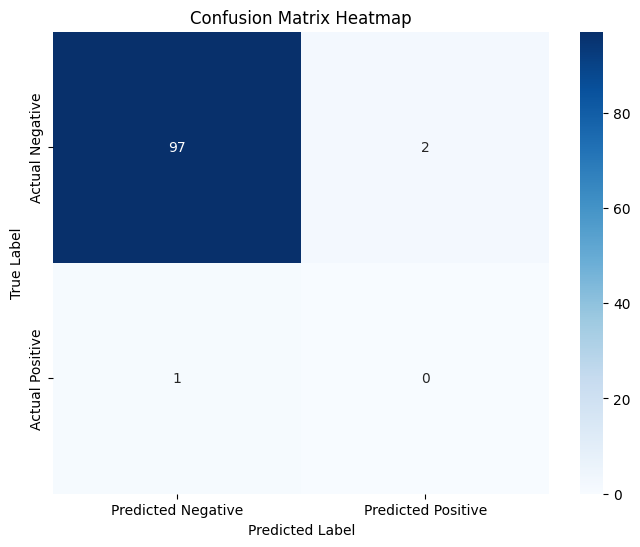

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

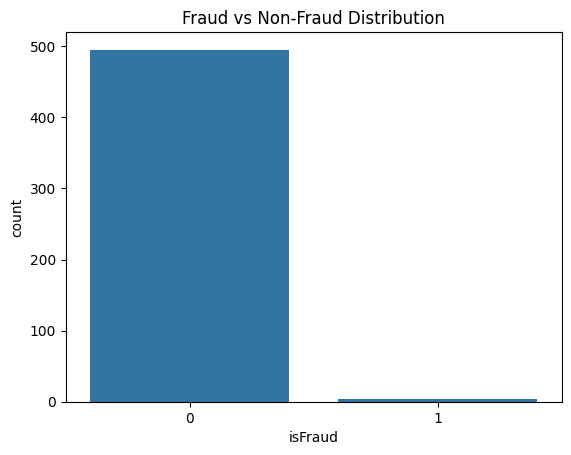

In [ ]:
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

In [ ]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

** 5. Model Development**

In [ ]:
y_train = (y_train > 0).astype(int)
y_test = (y_test > 0).astype(int)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed, y_train)
y_pred_log = log_model.predict(X_test_processed)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)

In [ ]:
print("RandomForest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Classification Report:")
print(classification_report(y_test,y_pred_rf))

roc_score = roc_auc_score(y_test, y_pred_rf)
print("ROC AUC Score:", roc_score)

RandomForest Confusion Matrix:
[[99  0]
 [ 1  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        99
           1       0.00      0.00      0.00         1

    accuracy                           0.99       100
   macro avg       0.49      0.50      0.50       100
weighted avg       0.98      0.99      0.99       100

ROC AUC Score: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
fraud_prob = rf_model.predict_proba(X_test_processed)[:,1]

risk_df = X_test.copy()
risk_df['Fraud_Probability'] = fraud_prob
risk_df['Actual_Label'] = y_test.values

high_risk = risk_df[risk_df['Fraud_Probability'] >= 0.7]

print("High Risk Transactions:")
print(high_risk.head())

High Risk Transactions:
Empty DataFrame
Columns: [step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig, nameDest, oldbalanceDest, newbalanceDest, isFlaggedFraud, Fraud_Probability, Actual_Label]
Index: []


           Feature  Importance
1           amount    0.415462
4   oldbalanceDest    0.204773
2    oldbalanceOrg    0.180731
7    type_CASH_OUT    0.058594
9     type_PAYMENT    0.056055
3   newbalanceOrig    0.038797
5   newbalanceDest    0.023002
10   type_TRANSFER    0.022415
8       type_DEBIT    0.000172
0             step    0.000000


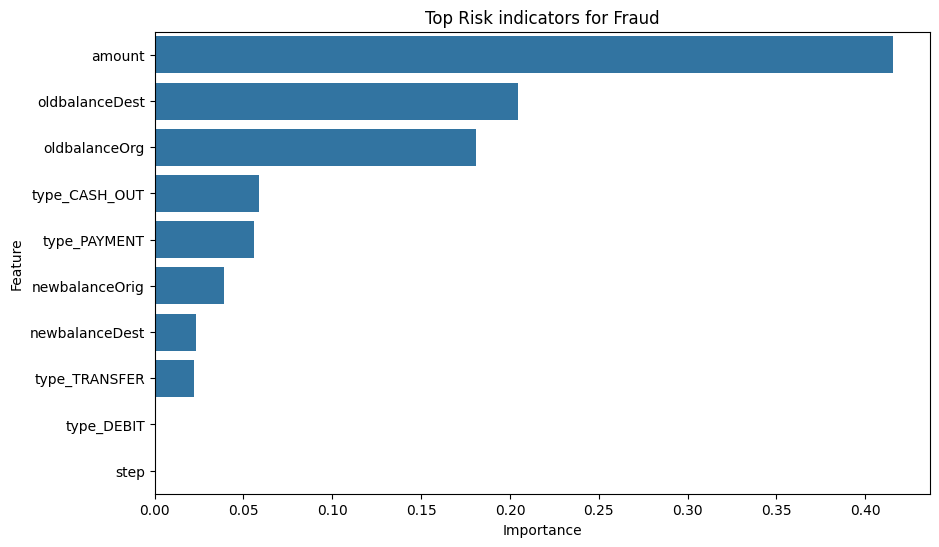

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top Risk indicators for Fraud')
plt.show()

In [ ]:
iso_model = IsolationForest(contamination=0.02, random_state=42)
# Use the preprocessed 'df' (excluding the target 'isFraud') for IsolationForest
X_for_anomaly_detection = df.drop('isFraud', axis=1)
df['Anomaly_Score'] = iso_model.fit_predict(X_for_anomaly_detection)

df['Anomaly_Label'] = df['Anomaly_Score'].apply(lambda x: 'Anomaly' if x == -1 else 0)

print(df['Anomaly_Label'].value_counts())

Anomaly_Label
0          489
Anomaly     10
Name: count, dtype: int64


In [ ]:
fraud_rate = df['isFraud'].mean()
print("Overall Fraud Rate:", fraud_rate)
high_risk_rate = len(high_risk) / len(df)
print("High Risk Transaction Rate:", high_risk_rate)

Overall Fraud Rate: 5.3397500182372256e-17
High Risk Transaction Rate: 0.0


**Credit card fraud**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Work/creditcard_fraud detection _26.02.2026.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284617 entries, 0 to 284616
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    200 non-null    float64
 1   V1      200 non-null    float64
 2   V2      200 non-null    float64
 3   V3      200 non-null    float64
 4   V4      200 non-null    float64
 5   V5      200 non-null    float64
 6   V6      200 non-null    float64
 7   V7      200 non-null    float64
 8   V8      200 non-null    float64
 9   V9      200 non-null    float64
 10  V10     200 non-null    float64
 11  V11     200 non-null    float64
 12  V12     200 non-null    float64
 13  V13     200 non-null    float64
 14  V14     200 non-null    float64
 15  V15     200 non-null    float64
 16  V16     200 non-null    float64
 17  V17     200 non-null    float64
 18  V18     200 non-null    float64
 19  V19     200 non-null    float64
 20  V20     200 non-null    float64
 21  V21     200 non-null    float64
 

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.0
mean,65.050000,-0.237177,0.163235,0.829396,0.361502,-0.046196,0.345448,0.236201,-0.013150,0.016972,...,0.018829,-0.024019,-0.049225,0.052874,0.144812,-0.004681,0.015952,-0.030918,92.905300,0.0
std,36.088355,1.475772,1.357175,1.133932,1.383139,1.269711,1.375483,0.857685,0.730426,0.818821,...,0.469162,0.625563,0.448876,0.606148,0.412452,0.507653,0.386392,0.307068,320.338982,0.0
min,0.000000,-6.093248,-12.114213,-5.694973,-4.515824,-6.631951,-2.145673,-2.705393,-3.807864,-2.094011,...,-0.923604,-2.776923,-3.553381,-1.688158,-1.120892,-1.243924,-2.377933,-1.648553,0.750000,0.0
25%,35.000000,-0.908927,-0.123163,0.184456,-0.458773,-0.612207,-0.514202,-0.153077,-0.174020,-0.399573,...,-0.201357,-0.477585,-0.164033,-0.374780,-0.106138,-0.330680,-0.049463,-0.044305,6.465000,0.0
50%,68.000000,-0.386709,0.256549,0.876099,0.496795,-0.107134,-0.019053,0.159663,0.050100,-0.047599,...,-0.042305,-0.002497,-0.050503,0.125398,0.156589,-0.089525,0.020354,0.020062,20.375000,0.0
75%,93.000000,1.107945,0.856151,1.522946,1.216294,0.430023,0.478940,0.647553,0.270883,0.332317,...,0.102520,0.341098,0.073099,0.437282,0.469777,0.208768,0.090367,0.063047,67.467500,0.0
max,132.000000,1.492936,4.847323,3.562770,4.075817,3.281972,5.122103,4.808426,1.592032,4.009259,...,2.270069,1.461535,2.458589,1.215279,1.136720,3.065576,2.490503,1.575380,3828.040000,0.0


In [ ]:
df.isnull().sum()

,0
Time,284417
V1,284417
V2,284417
V3,284417
V4,284417
V5,284417
V6,284417
V7,284417
V8,284417
V9,284417


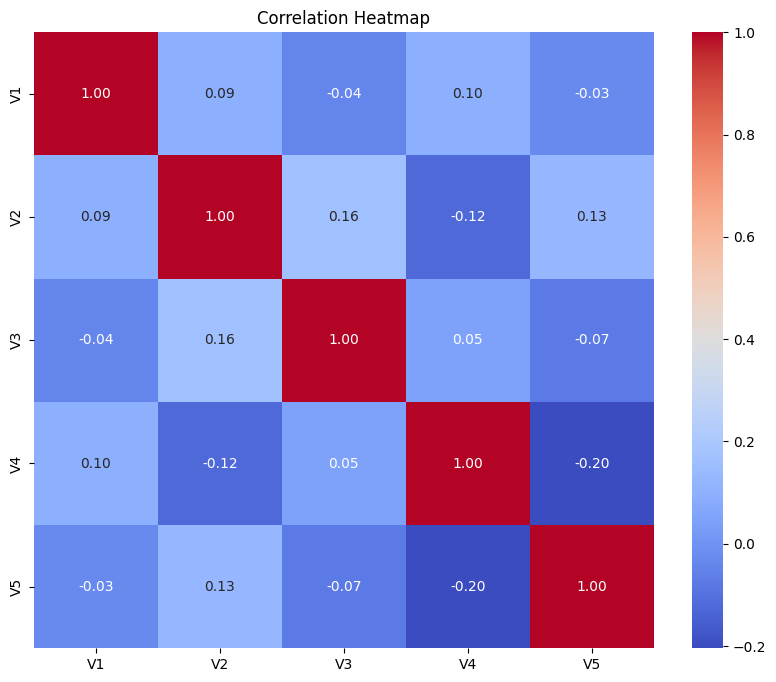

In [ ]:
numerical_cols = ['V1', 'V2', 'V3', 'V4', 'V5']
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)
corr_matrix = scaled_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Interpretation:**

**Diagonals (e.g., V1 with V1):** These are always 1, meaning a variable is perfectly correlated with itself, which is expected.

**Weak Correlations:** Most of the correlations between different V variables are relatively weak, with values close to 0 (e.g., V1 and V2 have a correlation of 0.09, V1 and V3 have -0.04). This suggests that there isn't a strong linear relationship between most of these pairs of features.

**Slightly Stronger, but still weak:** We observe some slightly stronger, but still weak, correlations like V2 and V3 (0.16) being positively correlated, and V4 and V5 (-0.20) being negatively correlated. Even these values are not particularly high, indicating that while there's a tendency, it's not a very strong one.


**3. Data Preparation**

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

In [ ]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

**5. Model Development**

In [ ]:
y_train = (y_train > 0).astype(int)
y_test = (y_test > 0).astype(int)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed, y_train)
y_pred_log = log_model.predict(X_test_processed)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)

In [ ]:
print("RandomForest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("Classification Report:")
print(classification_report(y_test,y_pred_rf))

roc_score = roc_auc_score(y_test, y_pred_rf)
print("ROC AUC Score:", roc_score)

RandomForest Confusion Matrix:
[[   21     2]
 [    4 56897]]
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        23
           1       1.00      1.00      1.00     56901

    accuracy                           1.00     56924
   macro avg       0.92      0.96      0.94     56924
weighted avg       1.00      1.00      1.00     56924

ROC AUC Score: 0.9564865903632778


In [ ]:
fraud_prob = rf_model.predict_proba(X_test_processed)[:,1]

risk_df = X_test.copy()
risk_df['Fraud_Probability'] = fraud_prob
risk_df['Actual_Label'] = y_test.values

high_risk = risk_df[risk_df['Fraud_Probability'] >= 0.7]

print("High Risk Transactions:")
print(high_risk.head())

High Risk Transactions:
        Time  V1  V2  V3  V4  V5  V6  V7  V8  V9  ...  V23  V24  V25  V26  \
51190    NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN   
240255   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN   
89465    NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN   
117596   NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN   
24819    NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ...  NaN  NaN  NaN  NaN   

        V27  V28  Amount  Class  Fraud_Probability  Actual_Label  
51190   NaN  NaN     NaN    NaN                1.0             1  
240255  NaN  NaN     NaN    NaN                1.0             1  
89465   NaN  NaN     NaN    NaN                1.0             1  
117596  NaN  NaN     NaN    NaN                1.0             1  
24819   NaN  NaN     NaN    NaN                1.0             1  

[5 rows x 32 columns]


   Feature  Importance
25     V28    0.089414
26  Amount    0.088560
17     V20    0.080754
11     V14    0.079441
22     V25    0.046444
9       V9    0.038884
6       V6    0.038865
5       V5    0.038514
15     V18    0.036322
16     V19    0.034968


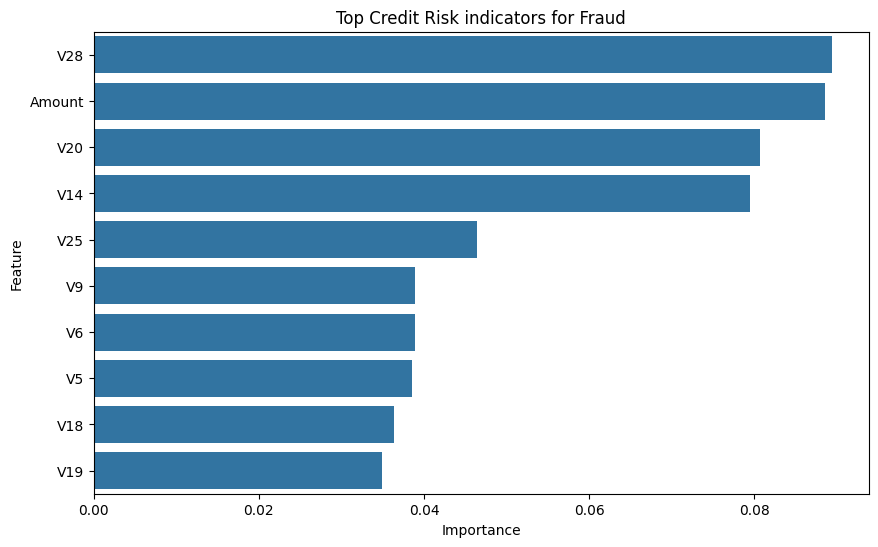

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top Credit Risk indicators for Fraud')
plt.show()

**Interpretation:**

This graph shows which features are most important for predicting fraud in credit card transactions. The taller bars mean those features are more significant. Here, 'V28' and 'Amount' are the top two indicators, meaning they play the biggest role in telling us if a transaction is fraudulent. 'V20' and 'V14' are also important. The 'V' features are coded details of the transaction, and the 'Amount' is simply how much money was involved

In [ ]:
iso_model = IsolationForest(contamination=0.02, random_state=42)
# Use the preprocessed 'df' (excluding the target 'isFraud') for IsolationForest
X_for_anomaly_detection = df.drop('V2', axis=1)
df['Anomaly_Score'] = iso_model.fit_predict(X_for_anomaly_detection)

df['Anomaly_Label'] = df['Anomaly_Score'].apply(lambda x: 'Anomaly' if x == -1 else 0)

print(df['Anomaly_Label'].value_counts())

Anomaly_Label
0          284417
Anomaly       200
Name: count, dtype: int64


In [ ]:
fraud_rate = df['V2'].mean()
print("Overall Credit Card Fraud Rate:", fraud_rate)
high_risk_rate = len(high_risk) / len(df)
print("High credit card Risk Transaction Rate:", high_risk_rate)

Overall Credit Card Fraud Rate: 1.5461578305552262e-15
High credit card Risk Transaction Rate: 0.19987210883397688


**Investment Analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Work/World-Stock-Prices-Dataset_Investment Aanlysis_26.02.2026.csv')

In [ ]:
df.head()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains
0,2025-07-03 00:00:00-04:00,6.630000,6.740000,6.615000,6.640000,4209664.0,peloton,PTON,fitness,usa,0.0,0.0,NaN
1,2025-07-03 00:00:00-04:00,106.750000,108.370003,106.330101,107.339996,560190.0,crocs,CROX,footwear,usa,0.0,0.0,NaN
2,2025-07-03 00:00:00-04:00,122.629997,123.050003,121.550003,121.930000,36600.0,adidas,ADDYY,apparel,germany,0.0,0.0,NaN
3,2025-07-03 00:00:00-04:00,221.705002,224.009995,221.360001,223.410004,29295154.0,amazon,AMZN,e-commerce,usa,0.0,0.0,NaN
4,2025-07-03 00:00:00-04:00,212.145004,214.649994,211.810104,213.550003,34697317.0,apple,AAPL,technology,usa,0.0,0.0,NaN


In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
count,310122.000000,310122.000000,310122.000000,310122.000000,3.101220e+05,310122.000000,310122.000000,2.0
mean,76.325431,77.198011,75.434586,76.338032,2.270937e+07,0.003643,0.000875,0.0
std,141.684070,143.224109,140.063617,141.679129,8.565744e+07,0.069905,0.115434,0.0
min,0.000000,0.000000,0.000000,0.198861,0.000000e+00,0.000000,0.000000,0.0
25%,15.932500,16.163165,15.710323,15.940000,1.379050e+06,0.000000,0.000000,0.0
50%,35.408120,35.809869,34.982469,35.407547,4.591642e+06,0.000000,0.000000,0.0
75%,83.996691,84.914656,83.088609,84.000000,1.212860e+07,0.000000,0.000000,0.0
max,3445.580078,3463.070068,3370.000000,3427.610107,7.421641e+09,15.000000,50.000000,0.0


In [ ]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Brand_Name,0
Ticker,0
Industry_Tag,0
Country,0


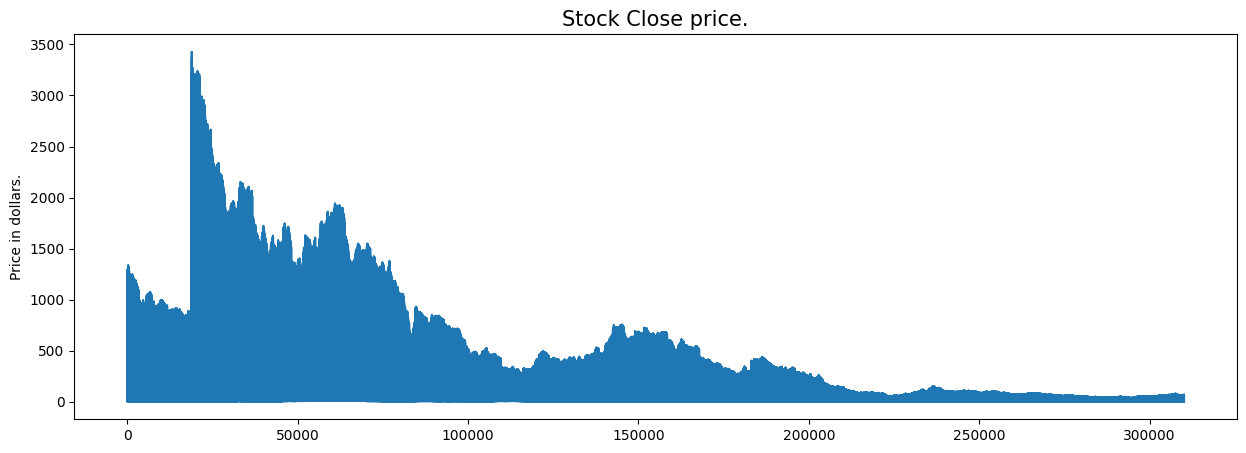

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('Stock Close price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.show()

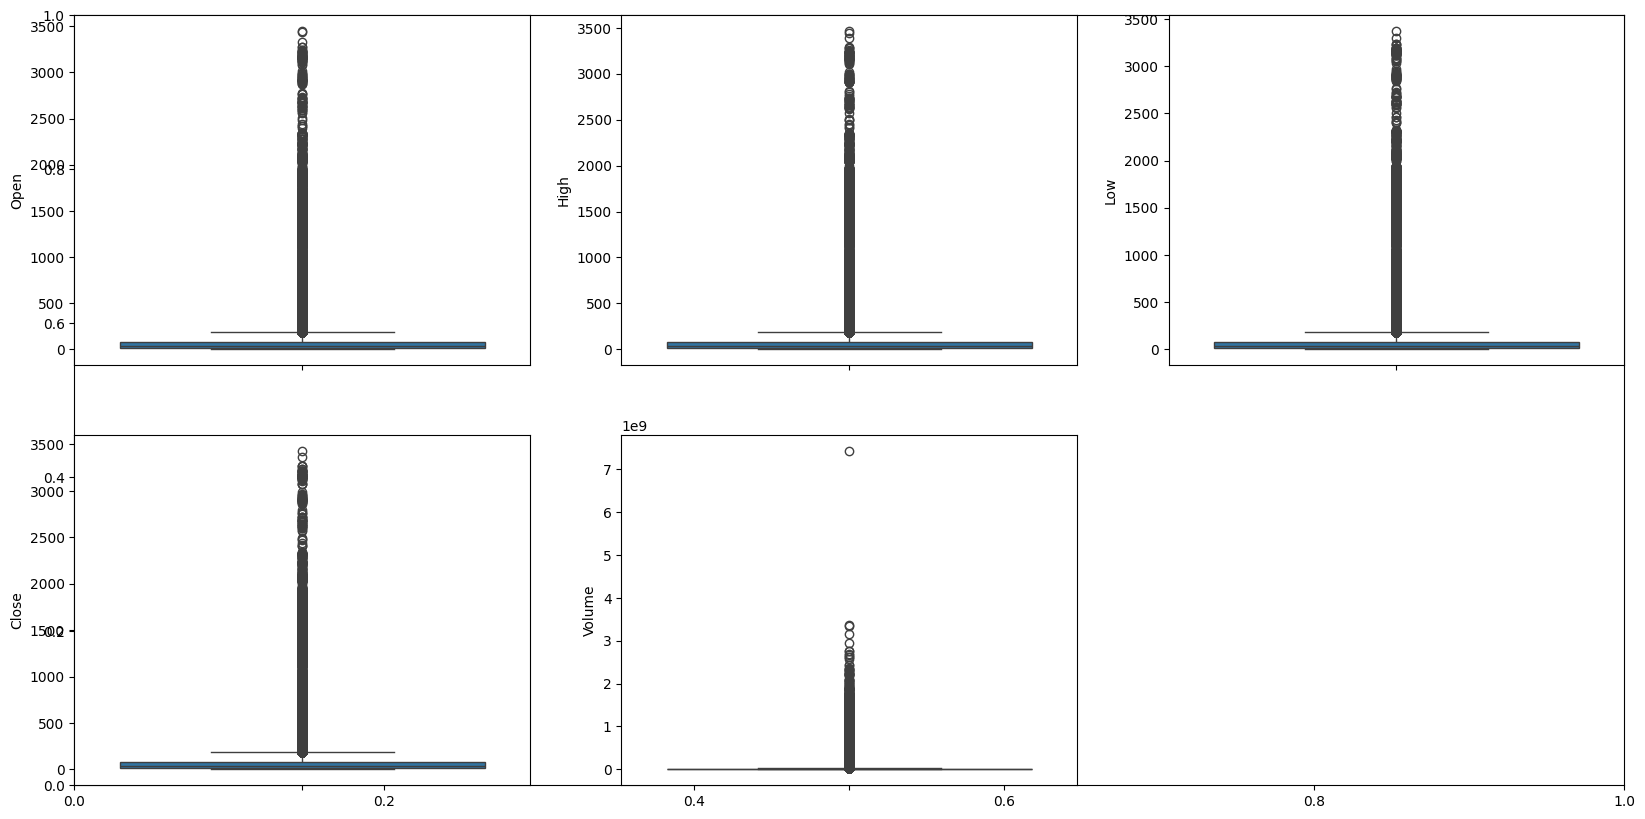

In [ ]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df['day'] = df['Date'].dt.day.astype('int')
df['month'] = df['Date'].dt.month.astype('int')
df['year'] = df['Date'].dt.year.astype('int')

df.head()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains,day,month,year,is_quarter_end,open-close,low-high,target
0,2025-07-03 04:00:00+00:00,6.630000,6.740000,6.615000,6.640000,4209664.0,peloton,PTON,fitness,usa,0.0,0.0,NaN,3,7,2025,0,-0.010000,-0.125000,1
1,2025-07-03 04:00:00+00:00,106.750000,108.370003,106.330101,107.339996,560190.0,crocs,CROX,footwear,usa,0.0,0.0,NaN,3,7,2025,0,-0.589996,-2.039902,1
2,2025-07-03 04:00:00+00:00,122.629997,123.050003,121.550003,121.930000,36600.0,adidas,ADDYY,apparel,germany,0.0,0.0,NaN,3,7,2025,0,0.699997,-1.500000,1
3,2025-07-03 04:00:00+00:00,221.705002,224.009995,221.360001,223.410004,29295154.0,amazon,AMZN,e-commerce,usa,0.0,0.0,NaN,3,7,2025,0,-1.705002,-2.649994,0
4,2025-07-03 04:00:00+00:00,212.145004,214.649994,211.810104,213.550003,34697317.0,apple,AAPL,technology,usa,0.0,0.0,NaN,3,7,2025,0,-1.404999,-2.839890,0


In [ ]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()

,Date,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains,day,month,year,is_quarter_end
0,2025-07-03 04:00:00+00:00,6.630000,6.740000,6.615000,6.640000,4209664.0,peloton,PTON,fitness,usa,0.0,0.0,NaN,3,7,2025,0
1,2025-07-03 04:00:00+00:00,106.750000,108.370003,106.330101,107.339996,560190.0,crocs,CROX,footwear,usa,0.0,0.0,NaN,3,7,2025,0
2,2025-07-03 04:00:00+00:00,122.629997,123.050003,121.550003,121.930000,36600.0,adidas,ADDYY,apparel,germany,0.0,0.0,NaN,3,7,2025,0
3,2025-07-03 04:00:00+00:00,221.705002,224.009995,221.360001,223.410004,29295154.0,amazon,AMZN,e-commerce,usa,0.0,0.0,NaN,3,7,2025,0
4,2025-07-03 04:00:00+00:00,212.145004,214.649994,211.810104,213.550003,34697317.0,apple,AAPL,technology,usa,0.0,0.0,NaN,3,7,2025,0


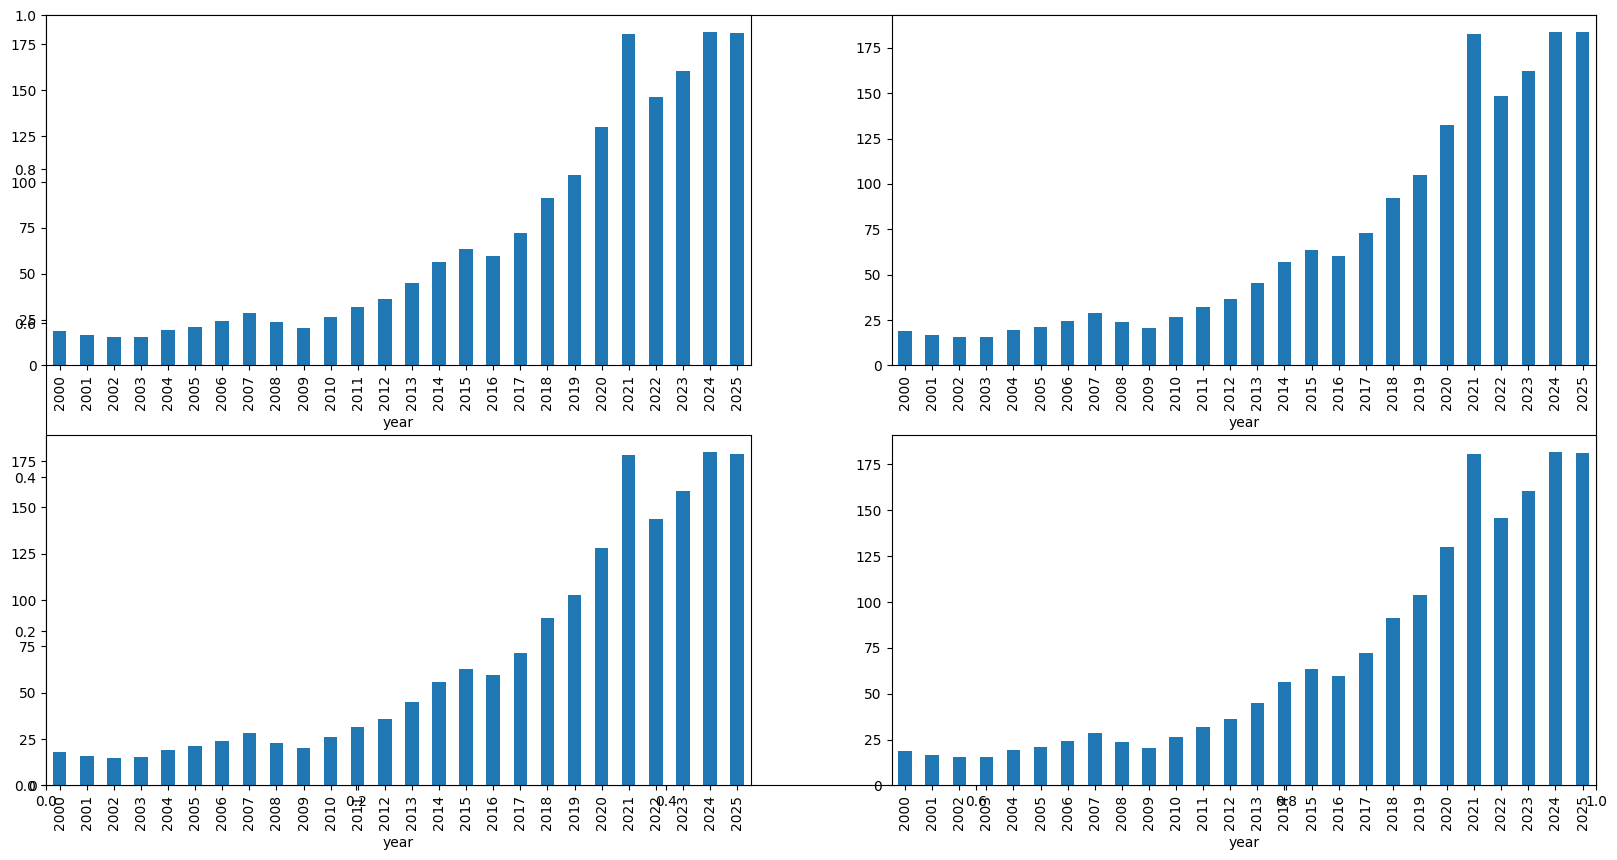

In [ ]:
data_grouped = df.drop('Date', axis=1).groupby('year').mean(numeric_only=True)
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

In [ ]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

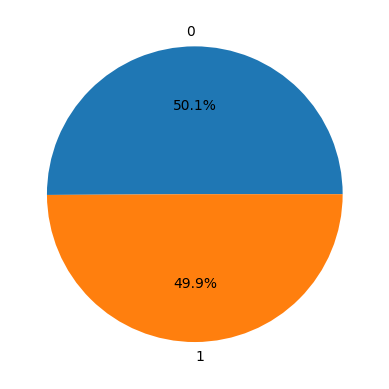

In [ ]:
plt.pie(df['target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

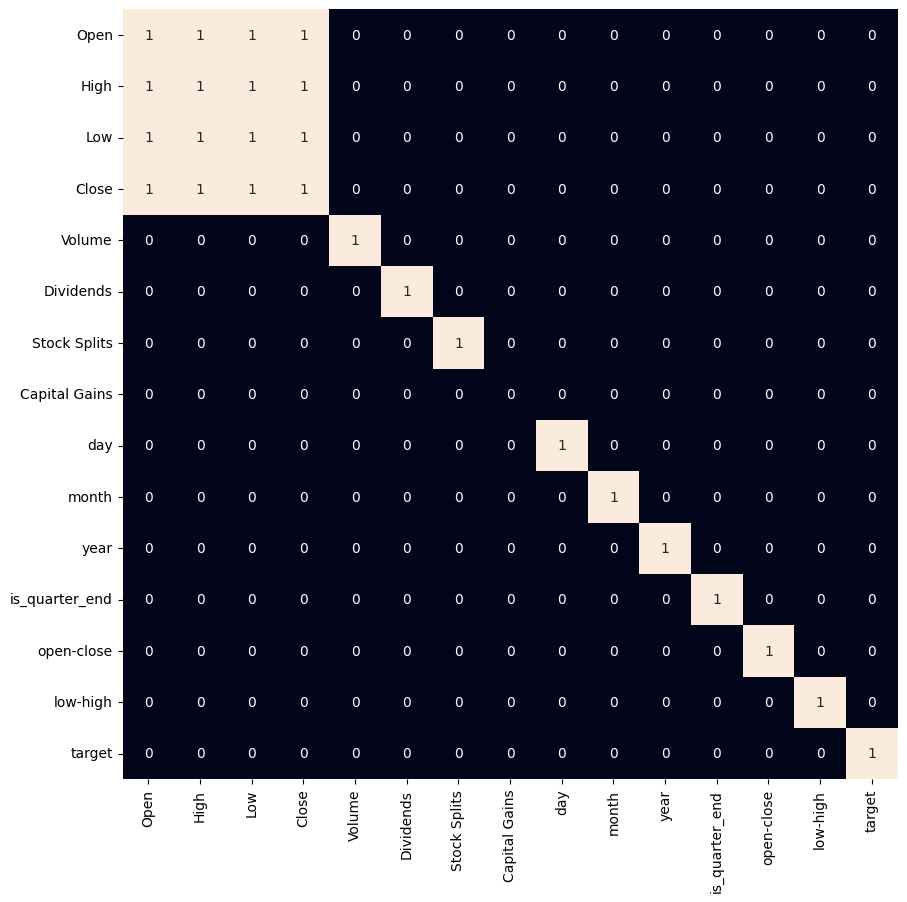

In [ ]:
plt.figure(figsize=(10, 10))

# As our concern is with the highly
# correlated features only so, we will visualize
# our heatmap as per that criteria only.
sb.heatmap(df.drop('Date', axis=1).corr(numeric_only=True) > 0.9, annot=True, cbar=False)
plt.show()

# This code is modified by Susobhan Akhuli

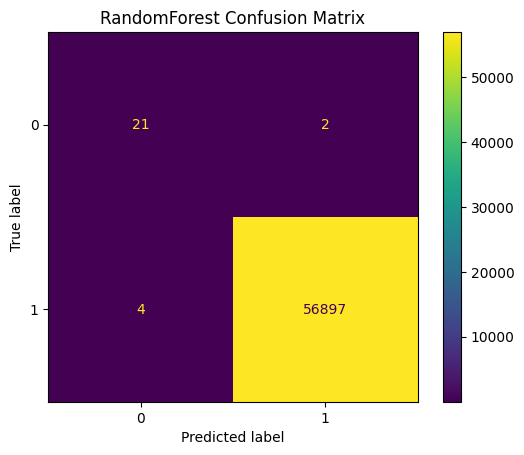

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming you want to display the confusion matrix for the RandomForestClassifier
# using the processed test data and true labels.
# If you intend to use a list of models or a different validation set, please define them first.
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_processed, y_test)
plt.title('RandomForest Confusion Matrix')
plt.show()

# Task
The time series plot of the 'Close' price from the 'World Stock Prices Dataset' has been successfully generated.

## Generate Time Series Plot

### Subtask:
Plot the 'Close' price over time from the 'World Stock Prices Dataset' to visualize its historical trend. This will create a line plot with the date on the x-axis and the 'Close' price on the y-axis, along with appropriate labels and title.


**Reasoning**:
The previous plot of the 'Close' price did not explicitly use the 'Date' column for the x-axis. To ensure the plot displays the 'Close' price against time (Date) as requested, I will regenerate the line plot using `df.plot()` with `x='Date'` and `y='Close'`, applying the specified title and y-axis label.



**Reasoning**:
The `KeyError: 'Date'` occurs because 'Date' is the DataFrame's index, not a column, when `df.plot(x='Date', ...)` is called. To correctly plot the 'Close' price against the 'Date' index, I will use `df['Close'].plot()` which automatically uses the Series' index for the x-axis.



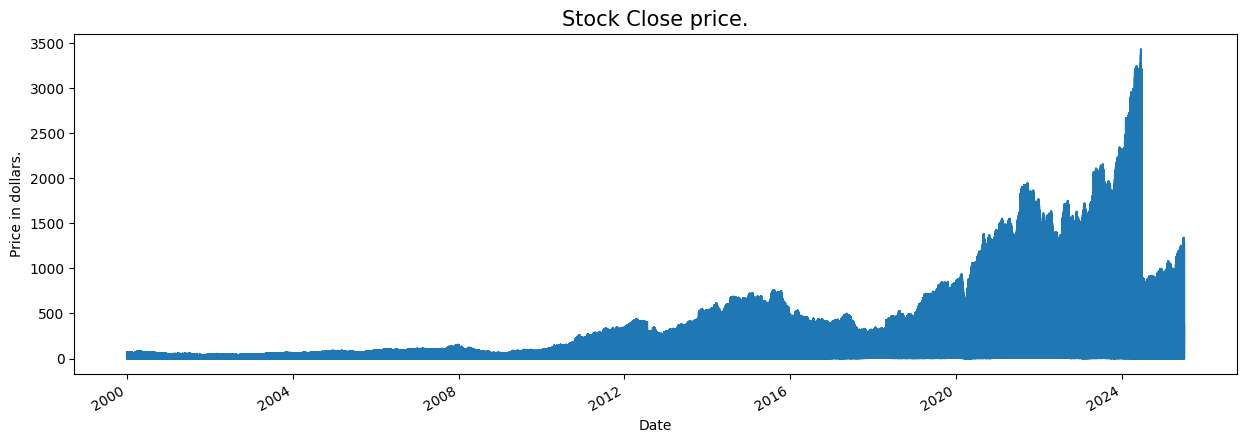

In [ ]:
plt.figure(figsize=(15,5))
df['Close'].plot(ax=plt.gca())
plt.title('Stock Close price.', fontsize=15)
plt.ylabel('Price in dollars.')
plt.xlabel('Date') # Explicitly setting x-label to 'Date'
plt.show()

## Summary:

### Data Analysis Key Findings
*   Initially, an attempt to plot 'Close' price against a 'Date' column resulted in a `KeyError`, indicating that 'Date' was the DataFrame's index rather than a regular column.
*   The issue was successfully resolved by plotting the `Close` series directly (`df['Close'].plot()`), which automatically uses the DataFrame's index (the Date) for the x-axis.
*   A time series plot of the 'Close' price was successfully generated, showing the 'Close' price against the date, with the title 'Stock Close price.' and the y-axis labeled 'Price in dollars.'

### Insights or Next Steps
*   Always verify if the date column is an index or a regular column when plotting time series data in pandas to avoid `KeyError`.
*   The generated plot provides a visual representation of the historical trend of the stock's closing price, which can be used for further technical analysis or trend identification.
